# Automated Cyberbullying Classification on Social Media Posts

# Step1: Business problem

- Cyberbullying on social media is increasing rapidly, and it causes severe psychological, emotional, and social harm to    individuals, especially teenagers and vulnerable groups.
- Manual moderation is not scalable, since millions of posts are generated every minute across platforms.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
df=pd.read_csv("C:\\Users\\Asus\\OneDrive\\Desktop\\power shheets\\Projects\\cyberbullying_classification_dataset.csv")
df.head()

,post_text,user_followers,user_age,account_age_days,time_posted,label
0,kids these days are dumb,99035,19,1005,Evening,3
1,men are weak,2007,63,3454,Morning,1
2,girls can't code,33717,33,4831,Morning,1
3,Love this new phone.,87997,50,246,Night,0
4,no one likes you,48400,16,893,Night,4


# Step2: Data Understanding

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   post_text         10000 non-null  object
 1   user_followers    10000 non-null  int64 
 2   user_age          10000 non-null  int64 
 3   account_age_days  10000 non-null  int64 
 4   time_posted       10000 non-null  object
 5   label             10000 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 468.9+ KB


In [36]:
df.describe()

,user_followers,user_age,account_age_days,label
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,50523.946100,41.579200,2494.364900,1.417300
std,28930.909046,16.707269,1447.906124,1.635551
min,0.000000,13.000000,1.000000,0.000000
25%,25709.000000,27.000000,1227.000000,0.000000
50%,50421.500000,42.000000,2488.000000,1.000000
75%,75361.500000,56.000000,3763.250000,3.000000
max,99981.000000,70.000000,5000.000000,4.000000


In [37]:
df['time_posted'].value_counts()

time_posted
Afternoon    2596
Morning      2485
Night        2484
Evening      2435
Name: count, dtype: int64

In [38]:
df['label'].unique()

array([3, 1, 0, 4, 2])

In [39]:
df['label'].value_counts()

label
0    4997
4    2047
3    1020
2     989
1     947
Name: count, dtype: int64

In [40]:
df['account_age_days'].max()

5000

In [41]:
df['user_age'].mean()

np.float64(41.5792)

In [42]:
df['user_followers'].mean()

np.float64(50523.9461)

In [43]:
df['time_posted'].mode()

0    Afternoon
Name: time_posted, dtype: object

In [44]:
df.isnull().sum()

post_text           0
user_followers      0
user_age            0
account_age_days    0
time_posted         0
label               0
dtype: int64

In [45]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Length: 10000, dtype: bool

In [46]:
contineous=['user_followers','user_age','account_age_days']

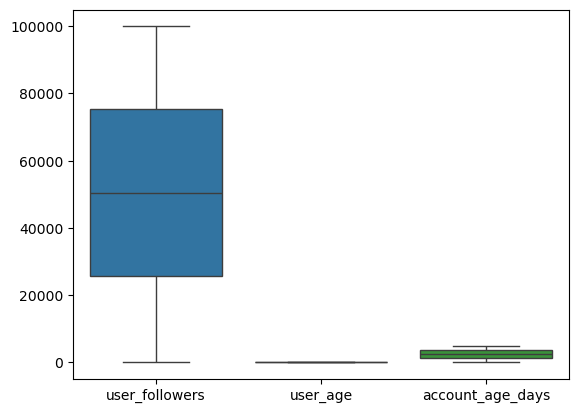

In [47]:
sns.boxplot(df[contineous])
plt.show()

# Step3: Data Cleaning

- No Data Cleaning Require

In [48]:
df.head(2)

,post_text,user_followers,user_age,account_age_days,time_posted,label
0,kids these days are dumb,99035,19,1005,Evening,3
1,men are weak,2007,63,3454,Morning,1


# Step4: Data Wrangling

In [49]:
from sklearn.preprocessing import OrdinalEncoder
oe=OrdinalEncoder()
df['time_posted']=oe.fit_transform(df[['time_posted']])

In [58]:
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
ps = PorterStemmer()
stop_words = set(stopwords.words("english"))
def clean_text(text):
    text = re.sub("[^a-zA-Z]", " ", str(text))
    text = text.lower().split()
    text = [ps.stem(word) for word in text if word not in stop_words]
    return " ".join(text)
df["clean_text"] = df["post_text"].apply(clean_text)
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=3,
    max_df=0.9
)
X_tfidf = vectorizer.fit_transform(df["clean_text"]).toarray()
df_tfidf = pd.DataFrame(X_tfidf, columns=vectorizer.get_feature_names_out())
x = pd.concat([df.drop(columns=["post_text", "clean_text"]), df_tfidf], axis=1)
print(x.head(2))

   user_followers  user_age  account_age_days  time_posted  label  babi  \
0           99035        19              1005          1.0      3   0.0   
1            2007        63              3454          2.0      1   0.0   

   birthday  boomer  boy  boy cri  ...  religion fake  save  stupid  tech  \
0       0.0     0.0  0.0      0.0  ...            0.0   0.0     0.0   0.0   
1       0.0     0.0  0.0      0.0  ...            0.0   0.0     0.0   0.0   

   use  use tech  useless  walk     weak  weekend  
0  0.0       0.0      0.0   0.0  0.00000      0.0  
1  0.0       0.0      0.0   0.0  0.57735      0.0  

[2 rows x 63 columns]


1. **Import libraries** → `re`, `nltk`, `sklearn` for cleaning & vectorization.
2. **Clean text** → lowercase, remove links, punctuation, numbers, emojis → `clean_text`.
3. **Preprocess text** → remove stopwords, apply stemming → `processed_text`.
4. **Convert text to numbers** → use `TfidfVectorizer` → creates numeric matrix of word importance.
5. **Create DataFrame** → merge original text, cleaned text, processed text, and numeric features.
6. **Result** → each post has numeric representation (TF-IDF features) → ready for ML models.

In [59]:
x.head()

,user_followers,user_age,account_age_days,time_posted,label,babi,birthday,boomer,boy,boy cri,...,religion fake,save,stupid,tech,use,use tech,useless,walk,weak,weekend
0,99035,19,1005,1.0,3,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
1,2007,63,3454,2.0,1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.57735,0.0
2,33717,33,4831,2.0,1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
3,87997,50,246,3.0,0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
4,48400,16,893,3.0,4,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0


# Step5: Modeling

# X and Y

In [61]:
#X=x.drop('label',axis=1)
y=x['label']

# Train,Test Split

In [62]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [63]:
import warnings
warnings.filterwarnings("ignore")
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(class_weight="balanced", max_iter=1000)
model.fit(X_train,y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [64]:
# print("Intercept:",model.intercept_)
# print("Coificcent:",model.coef_)

# Prediction

In [65]:
ypred_train=model.predict(X_train)
ypred_train

array([2, 4, 0, ..., 1, 0, 4])

In [66]:
ypred_test=model.predict(X_test)
ypred_test

array([0, 4, 0, ..., 0, 1, 0])

# Step6: Cross validation and Accuracy Score

In [67]:
from sklearn.model_selection import cross_val_score
print("cross validation score:",cross_val_score(model,X_train,y_train,cv=5).mean())
from sklearn.metrics import accuracy_score
print("accuracy_score",accuracy_score(ypred_train,y_train))

cross validation score: 0.946
accuracy_score 0.95125


In [68]:
from sklearn.model_selection import cross_val_score
print("cross validation score:",cross_val_score(model,X_test,y_test,cv=5).mean())
from sklearn.metrics import accuracy_score
print("accuracy_score",accuracy_score(ypred_test,y_test))

cross validation score: 0.8675
accuracy_score 0.9455


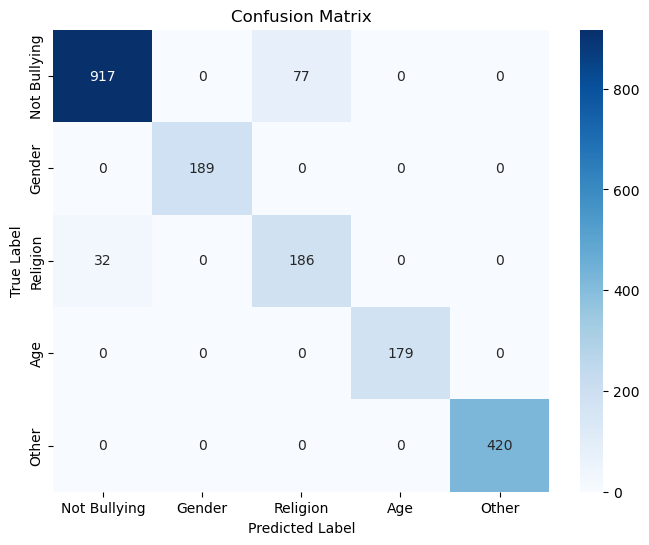

Classification Report:

                          precision    recall  f1-score   support

            Not Bullying       0.97      0.92      0.94       994
  Cyberbullying (Gender)       1.00      1.00      1.00       189
Cyberbullying (Religion)       0.71      0.85      0.77       218
     Cyberbullying (Age)       1.00      1.00      1.00       179
   Cyberbullying (Other)       1.00      1.00      1.00       420

                accuracy                           0.95      2000
               macro avg       0.93      0.96      0.94      2000
            weighted avg       0.95      0.95      0.95      2000



In [69]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", 
            xticklabels=["Not Bullying", "Gender", "Religion", "Age", "Other"],
            yticklabels=["Not Bullying", "Gender", "Religion", "Age", "Other"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=[
    "Not Bullying",
    "Cyberbullying (Gender)",
    "Cyberbullying (Religion)",
    "Cyberbullying (Age)",
    "Cyberbullying (Other)"
]))

In [70]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")
print("Overall Accuracy:", round(accuracy, 4))
print("Overall Precision:", round(precision, 4))
print("Overall Recall:", round(recall, 4))
print("Overall F1-score:", round(f1, 4))

Overall Accuracy: 0.9455
Overall Precision: 0.9347
Overall Recall: 0.9551
Overall F1-score: 0.9435


In [71]:
import pickle
with open("vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)
print("Model and Vectorizer saved successfully!")

Model and Vectorizer saved successfully!
